['ID_27a354d42.dcm', 'ID_9ef779a18.dcm', 'ID_5bed38bf6.dcm', 'ID_286599272.dcm', 'ID_bba76cea8.dcm']


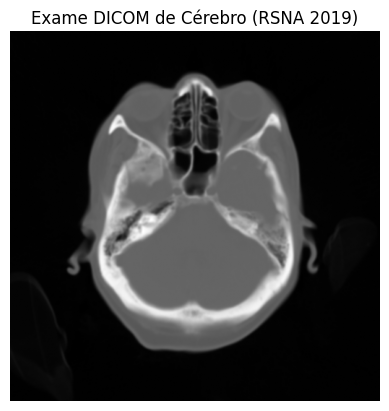

In [7]:
import pydicom
import matplotlib.pyplot as plt
import os

DATASET_DIR = '/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection'
IMG_DIR = f'{DATASET_DIR}/stage_2_train'

# pega só os 5 primeiros nomes de arquivo da pasta (rápido, não escaneia tudo)
arquivos = os.listdir(IMG_DIR)[:5]
print(arquivos)

# lê e mostra o primeiro
dcm = pydicom.dcmread(f'{IMG_DIR}/{arquivos[0]}')
plt.imshow(dcm.pixel_array, cmap='gray')
plt.axis('off')
plt.title("Exame DICOM de Cérebro (RSNA 2019)")
plt.show()

In [8]:
import pandas as pd

csv_path = f'{DATASET_DIR}/stage_2_train.csv'
labels_raw = pd.read_csv(csv_path)
print(labels_raw.shape)
labels_raw.head()

(4516842, 2)


,ID,Label
0,ID_12cadc6af_epidural,0
1,ID_12cadc6af_intraparenchymal,0
2,ID_12cadc6af_intraventricular,0
3,ID_12cadc6af_subarachnoid,0
4,ID_12cadc6af_subdural,0


In [9]:
# verifica quantas duplicatas existem
print("Linhas antes:", labels_raw.shape[0])
print("IDs duplicados:", labels_raw['ID'].duplicated().sum())

# remove duplicatas, mantendo a primeira ocorrência
labels_raw = labels_raw.drop_duplicates(subset=['ID']).reset_index(drop=True)
print("Linhas depois:", labels_raw.shape[0])

Linhas antes: 4516842
IDs duplicados: 24
Linhas depois: 4516818


In [10]:
# recria as colunas separadas
labels_raw[['image_id', 'subtype']] = labels_raw['ID'].str.rsplit('_', n=1, expand=True)

# checa duplicatas na combinação real usada no pivot
dup_count = labels_raw.duplicated(subset=['image_id', 'subtype']).sum()
print("Duplicatas (image_id, subtype):", dup_count)

# pivot_table tolera duplicatas: pega o primeiro valor de cada combinação
labels_wide = labels_raw.pivot_table(
    index='image_id', columns='subtype', values='Label', aggfunc='first'
).reset_index()

print(labels_wide.shape)
labels_wide.head()

Duplicatas (image_id, subtype): 0
(752803, 7)


subtype,image_id,any,epidural,intraparenchymal,intraventricular,subarachnoid,subdural
0,ID_000012eaf,0,0,0,0,0,0
1,ID_000039fa0,0,0,0,0,0,0
2,ID_00005679d,0,0,0,0,0,0
3,ID_00008ce3c,0,0,0,0,0,0
4,ID_0000950d7,0,0,0,0,0,0


In [11]:
subtype_cols = ['any', 'epidural', 'intraparenchymal', 'intraventricular',
                 'subarachnoid', 'subdural']

print("Total de imagens:", len(labels_wide))
print("\nContagem de positivos por subtipo:")
print(labels_wide[subtype_cols].sum())

print("\nProporção de positivos (%):")
print((labels_wide[subtype_cols].mean() * 100).round(2))

Total de imagens: 752803

Contagem de positivos por subtipo:
subtype
any                 107933
epidural              3145
intraparenchymal     36118
intraventricular     26205
subarachnoid         35675
subdural             47166
dtype: int64

Proporção de positivos (%):
subtype
any                 14.34
epidural             0.42
intraparenchymal     4.80
intraventricular     3.48
subarachnoid         4.74
subdural             6.27
dtype: float64


In [12]:
import numpy as np

SEED = 42
rng = np.random.default_rng(SEED)

N_POS = 500  # imagens com "any"=1
N_NEG = 500  # imagens com "any"=0

pos_pool = labels_wide[labels_wide['any'] == 1]
neg_pool = labels_wide[labels_wide['any'] == 0]

pos_sample = pos_pool.sample(n=N_POS, random_state=SEED)
neg_sample = neg_pool.sample(n=N_NEG, random_state=SEED)

sample_df = pd.concat([pos_sample, neg_sample]).reset_index(drop=True)

print("Tamanho da amostra:", len(sample_df))
print("\nDistribuição na amostra:")
print(sample_df[subtype_cols].sum())

Tamanho da amostra: 1000

Distribuição na amostra:
subtype
any                 500
epidural             16
intraparenchymal    186
intraventricular    119
subarachnoid        171
subdural            211
dtype: int64


In [13]:
import pydicom
from tqdm import tqdm

IMG_DIR = f'{DATASET_DIR}/stage_2_train'

registros = []
for image_id in tqdm(sample_df['image_id']):
    path = f'{IMG_DIR}/{image_id}.dcm'
    ds = pydicom.dcmread(path, stop_before_pixels=True)  # não lê pixel, só metadado -> mais rápido
    registros.append({
        'image_id': image_id,
        'PatientID': ds.get('PatientID', None),
        'Modality': ds.get('Modality', None),
        'PixelSpacing': str(ds.get('PixelSpacing', None)),
        'WindowCenter': str(ds.get('WindowCenter', None)),
        'WindowWidth': str(ds.get('WindowWidth', None)),
        'RescaleSlope': ds.get('RescaleSlope', None),
        'RescaleIntercept': ds.get('RescaleIntercept', None),
        'Rows': ds.get('Rows', None),
        'Columns': ds.get('Columns', None),
    })

meta_df = pd.DataFrame(registros)
meta_df.head()

100%|██████████| 1000/1000 [00:36<00:00, 27.68it/s]


,image_id,PatientID,Modality,PixelSpacing,WindowCenter,WindowWidth,RescaleSlope,RescaleIntercept,Rows,Columns
0,ID_de26946f2,ID_b0d7d385,CT,"[0.494750976563, 0.494750976563]",35.000000,135.000000,1.0,-1024.0,512,512
1,ID_b605ea8c3,ID_6c30db4d,CT,"[0.48828125, 0.48828125]","[00040, 00040]","[00080, 00080]",1.0,-1024.0,512,512
2,ID_4beaa703d,ID_de372b46,CT,"[0.488281, 0.488281]",30,80,1.0,-1024.0,512,512
3,ID_0e9261893,ID_7e0fb870,CT,"[0.488281, 0.488281]",40,150,1.0,0.0,512,512
4,ID_dd5569001,ID_870e65ad,CT,"[0.48828125, 0.48828125]","[00040, 00040]","[00080, 00080]",1.0,-1024.0,512,512


In [14]:
print("Imagens na amostra:", len(meta_df))
print("Pacientes únicos:", meta_df['PatientID'].nunique())
print("\nModalidade:")
print(meta_df['Modality'].value_counts())
print("\nExemplo de PixelSpacing:", meta_df['PixelSpacing'].iloc[0])

Imagens na amostra: 1000
Pacientes únicos: 965

Modalidade:
Modality
CT    1000
Name: count, dtype: int64

Exemplo de PixelSpacing: [0.494750976563, 0.494750976563]


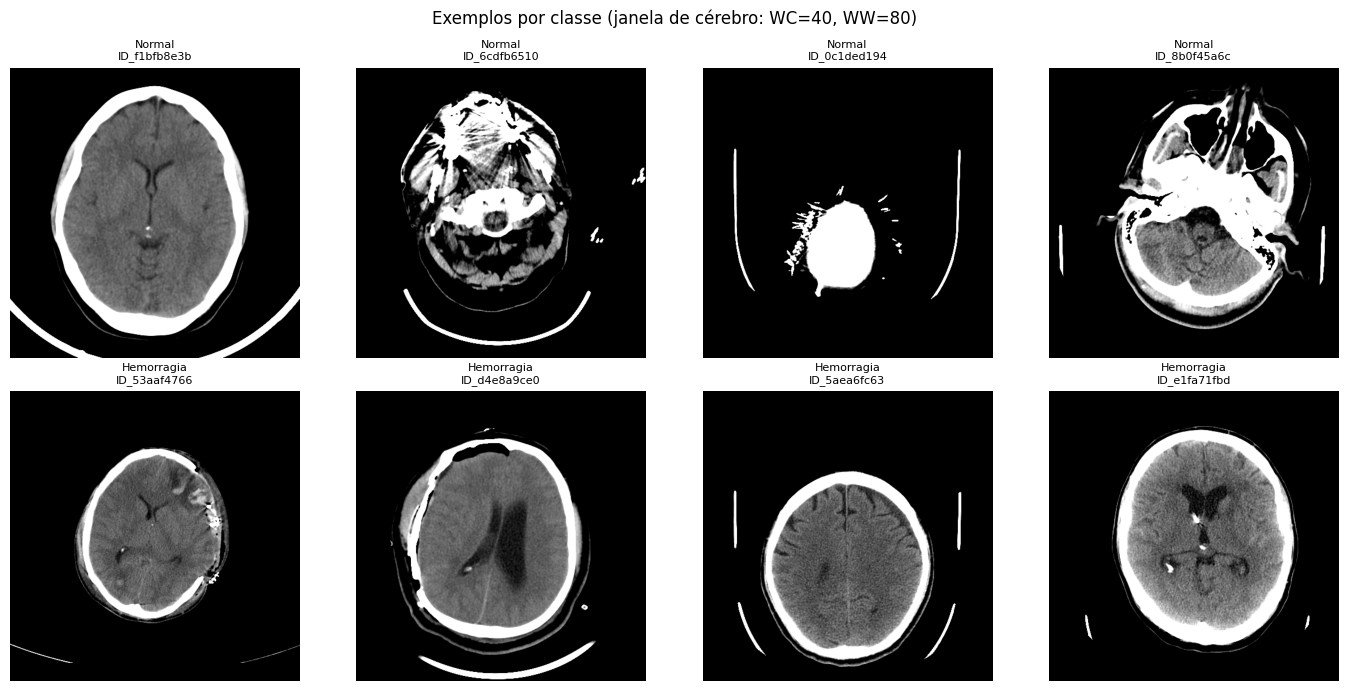

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pydicom

def aplicar_janela(ds, wc, ww):
    img = ds.pixel_array.astype(np.float32) * ds.RescaleSlope + ds.RescaleIntercept
    lo, hi = wc - ww/2, wc + ww/2
    img = np.clip(img, lo, hi)
    return (img - lo) / (hi - lo)

# pega 4 exemplos "any=0" e 4 exemplos "any=1" da amostra
neg_ids = sample_df[sample_df['any'] == 0]['image_id'].sample(4, random_state=42).tolist()
pos_ids = sample_df[sample_df['any'] == 1]['image_id'].sample(4, random_state=42).tolist()

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for ax, img_id in zip(axes[0], neg_ids):
    ds = pydicom.dcmread(f'{IMG_DIR}/{img_id}.dcm')
    img = aplicar_janela(ds, wc=40, ww=80)  # janela de "cérebro"
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Normal\n{img_id}', fontsize=8)
    ax.axis('off')

for ax, img_id in zip(axes[1], pos_ids):
    ds = pydicom.dcmread(f'{IMG_DIR}/{img_id}.dcm')
    img = aplicar_janela(ds, wc=40, ww=80)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Hemorragia\n{img_id}', fontsize=8)
    ax.axis('off')

plt.suptitle('Exemplos por classe (janela de cérebro: WC=40, WW=80)')
plt.tight_layout()
plt.savefig('exemplos_por_classe.png', dpi=150)
plt.show()

In [16]:
import os, pandas as pd, numpy as np, pydicom
import matplotlib.pyplot as plt

DATASET_DIR = '/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection'
IMG_DIR = f'{DATASET_DIR}/stage_2_train'

labels_raw = pd.read_csv(f'{DATASET_DIR}/stage_2_train.csv')
labels_raw[['image_id', 'subtype']] = labels_raw['ID'].str.rsplit('_', n=1, expand=True)
labels_wide = labels_raw.pivot_table(index='image_id', columns='subtype', values='Label', aggfunc='first').reset_index()

subtype_cols = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

SEED = 42
N_POS, N_NEG = 500, 500
pos_sample = labels_wide[labels_wide['any'] == 1].sample(n=N_POS, random_state=SEED)
neg_sample = labels_wide[labels_wide['any'] == 0].sample(n=N_NEG, random_state=SEED)
sample_df = pd.concat([pos_sample, neg_sample]).reset_index(drop=True)

print("Recarregado. Amostra:", len(sample_df))

Recarregado. Amostra: 1000


In [17]:
from sklearn.model_selection import StratifiedGroupKFold

# precisamos do PatientID de cada imagem da amostra
registros = []
for image_id in sample_df['image_id']:
    ds = pydicom.dcmread(f'{IMG_DIR}/{image_id}.dcm', stop_before_pixels=True)
    registros.append({'image_id': image_id, 'PatientID': ds.get('PatientID', None)})

meta_df = pd.DataFrame(registros)
sample_df = sample_df.merge(meta_df, on='image_id')

print("Imagens:", len(sample_df))
print("Pacientes únicos:", sample_df['PatientID'].nunique())

# divide em treino (80%) e teste (20%), agrupando por paciente, estratificado por 'any'
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
X = sample_df['image_id']
y = sample_df['any']
groups = sample_df['PatientID']

train_idx, test_idx = next(sgkf.split(X, y, groups))

sample_df['split'] = 'train'
sample_df.loc[test_idx, 'split'] = 'test'

print("\nDistribuição do split:")
print(sample_df['split'].value_counts())
print("\nProporção de 'any' positivo em cada split:")
print(sample_df.groupby('split')['any'].mean())

# checagem de segurança: nenhum paciente pode aparecer nos dois splits
pacientes_treino = set(sample_df[sample_df['split']=='train']['PatientID'])
pacientes_teste = set(sample_df[sample_df['split']=='test']['PatientID'])
print("\nVazamento de pacientes entre splits:", len(pacientes_treino & pacientes_teste))

Imagens: 1000
Pacientes únicos: 965

Distribuição do split:
split
train    801
test     199
Name: count, dtype: int64

Proporção de 'any' positivo em cada split:
split
test     0.477387
train    0.505618
Name: any, dtype: float64

Vazamento de pacientes entre splits: 0


In [18]:
sample_df.to_csv('particao_congelada.csv', index=False)
print("Partição salva em particao_congelada.csv")
sample_df.head()

Partição salva em particao_congelada.csv


,image_id,any,epidural,intraparenchymal,intraventricular,subarachnoid,subdural,PatientID,split
0,ID_de26946f2,1,0,1,1,1,0,ID_b0d7d385,train
1,ID_b605ea8c3,1,0,0,0,1,0,ID_6c30db4d,train
2,ID_4beaa703d,1,0,1,0,1,1,ID_de372b46,train
3,ID_0e9261893,1,0,0,1,1,0,ID_7e0fb870,train
4,ID_dd5569001,1,0,1,0,0,0,ID_870e65ad,train


In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score, f1_score

train = sample_df[sample_df['split'] == 'train']
test = sample_df[sample_df['split'] == 'test']

# baseline: sempre prevê a classe majoritária
dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy.fit(np.zeros((len(train), 1)), train['any'])

pred_test = dummy.predict(np.zeros((len(test), 1)))
proba_test = dummy.predict_proba(np.zeros((len(test), 1)))[:, 1]

print("=== Baseline trivial (classe majoritária) ===")
print("Acurácia:", (pred_test == test['any']).mean())
print("Acurácia balanceada:", balanced_accuracy_score(test['any'], pred_test))
print("F1:", f1_score(test['any'], pred_test, zero_division=0))
try:
    print("AUC-ROC:", roc_auc_score(test['any'], proba_test))
except ValueError:
    print("AUC-ROC: indefinido (dummy só prevê uma classe)")

=== Baseline trivial (classe majoritária) ===
Acurácia: 0.47738693467336685
Acurácia balanceada: 0.5
F1: 0.6462585034013606
AUC-ROC: 0.5


In [20]:
from skimage.feature import local_binary_pattern
from skimage.transform import resize
import warnings
warnings.filterwarnings('ignore')

def carregar_e_janelar(image_id, wc=40, ww=80, tamanho=128):
    ds = pydicom.dcmread(f'{IMG_DIR}/{image_id}.dcm')
    img = ds.pixel_array.astype(np.float32) * ds.RescaleSlope + ds.RescaleIntercept
    lo, hi = wc - ww/2, wc + ww/2
    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo)
    img = resize(img, (tamanho, tamanho))  # padroniza tamanho
    return img

def extrair_lbp(img, P=8, R=1):
    img_uint8 = (img * 255).astype(np.uint8)
    lbp = local_binary_pattern(img_uint8, P, R, method='uniform')
    n_bins = P + 2
    hist, _ = np.histogram(lbp, bins=n_bins, range=(0, n_bins))
    hist = hist.astype(np.float32)
    hist /= (hist.sum() + 1e-6)  # normaliza
    return hist

# testa em 1 imagem
img_teste = carregar_e_janelar(sample_df['image_id'].iloc[0])
feat_teste = extrair_lbp(img_teste)
print("Formato da imagem:", img_teste.shape)
print("Formato do vetor LBP:", feat_teste.shape)
print("Exemplo de vetor:", feat_teste)

Formato da imagem: (128, 128)
Formato do vetor LBP: (10,)
Exemplo de vetor: [0.02148438 0.02624512 0.02099609 0.04559326 0.09521484 0.06176758
 0.02258301 0.02374268 0.64001465 0.0423584 ]


In [21]:
from tqdm import tqdm

features_lbp = []
for image_id in tqdm(sample_df['image_id']):
    img = carregar_e_janelar(image_id)
    feat = extrair_lbp(img)
    features_lbp.append(feat)

X_lbp = np.array(features_lbp)
print("Formato da matriz de características:", X_lbp.shape)

100%|██████████| 1000/1000 [00:15<00:00, 66.57it/s]

Formato da matriz de características: (1000, 10)


In [22]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# separa treino/teste usando a MESMA partição já congelada
train_mask = (sample_df['split'] == 'train').values
test_mask = (sample_df['split'] == 'test').values

X_train, X_test = X_lbp[train_mask], X_lbp[test_mask]
y_train, y_test = sample_df.loc[train_mask, 'any'], sample_df.loc[test_mask, 'any']

# pipeline: normalização + SVM (normalizador ajustado SÓ no treino, evita vazamento - §10 erro #2)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=SEED))
])

pipe.fit(X_train, y_train)

proba_test = pipe.predict_proba(X_test)[:, 1]
pred_test = pipe.predict(X_test)

print("=== LBP + SVM (RBF) ===")
print("Acurácia balanceada:", balanced_accuracy_score(y_test, pred_test))
print("F1:", f1_score(y_test, pred_test, zero_division=0))
print("AUC-ROC:", roc_auc_score(y_test, proba_test))
print("AUC-PR:", average_precision_score(y_test, proba_test))
print("\n(Baseline trivial tinha AUC-ROC = 0.5 — compare com o resultado acima)")


=== LBP + SVM (RBF) ===
Acurácia balanceada: 0.6600708502024291
F1: 0.6905829596412556
AUC-ROC: 0.7097165991902834
AUC-PR: 0.6398719212286423

(Baseline trivial tinha AUC-ROC = 0.5 — compare com o resultado acima)


In [23]:
resultados = []

resultados.append({
    'descritor': 'baseline_trivial',
    'modelo': 'DummyClassifier',
    'acuracia_balanceada': 0.5,
    'f1': 0.6463,
    'auc_roc': 0.5,
    'auc_pr': None
})

resultados.append({
    'descritor': 'LBP',
    'modelo': 'SVM_RBF',
    'acuracia_balanceada': balanced_accuracy_score(y_test, pred_test),
    'f1': f1_score(y_test, pred_test, zero_division=0),
    'auc_roc': roc_auc_score(y_test, proba_test),
    'auc_pr': average_precision_score(y_test, proba_test)
})

tabela_resultados = pd.DataFrame(resultados)
tabela_resultados.to_csv('tabela_resultados.csv', index=False)
tabela_resultados

,descritor,modelo,acuracia_balanceada,f1,auc_roc,auc_pr
0,baseline_trivial,DummyClassifier,0.500000,0.646300,0.500000,NaN
1,LBP,SVM_RBF,0.660071,0.690583,0.709717,0.639872


In [24]:
from skimage.feature import hog

def extrair_hog(img):
    features, _ = hog(
        img,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=True,
        feature_vector=True
    )
    return features

# testa em 1 imagem primeiro
img_teste = carregar_e_janelar(sample_df['image_id'].iloc[0])
feat_teste = extrair_hog(img_teste)
print("Formato do vetor HOG:", feat_teste.shape)

Formato do vetor HOG: (1764,)


In [25]:
features_hog = []
for image_id in tqdm(sample_df['image_id']):
    img = carregar_e_janelar(image_id)
    feat = extrair_hog(img)
    features_hog.append(feat)

X_hog = np.array(features_hog)
print("Formato da matriz HOG:", X_hog.shape)

100%|██████████| 1000/1000 [00:23<00:00, 42.82it/s]

Formato da matriz HOG: (1000, 1764)


In [26]:
features_hog = []
for image_id in tqdm(sample_df['image_id']):
    img = carregar_e_janelar(image_id)
    feat = extrair_hog(img)
    features_hog.append(feat)

X_hog = np.array(features_hog)
print("Formato da matriz HOG:", X_hog.shape)

100%|██████████| 1000/1000 [00:23<00:00, 42.81it/s]

Formato da matriz HOG: (1000, 1764)


In [27]:
X_train_hog, X_test_hog = X_hog[train_mask], X_hog[test_mask]

pipe_hog = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=SEED))
])

pipe_hog.fit(X_train_hog, y_train)

proba_test_hog = pipe_hog.predict_proba(X_test_hog)[:, 1]
pred_test_hog = pipe_hog.predict(X_test_hog)

print("=== HOG + SVM (RBF) ===")
print("Acurácia balanceada:", balanced_accuracy_score(y_test, pred_test_hog))
print("F1:", f1_score(y_test, pred_test_hog, zero_division=0))
print("AUC-ROC:", roc_auc_score(y_test, proba_test_hog))
print("AUC-PR:", average_precision_score(y_test, proba_test_hog))

# adiciona na tabela de resultados
resultados.append({
    'descritor': 'HOG',
    'modelo': 'SVM_RBF',
    'acuracia_balanceada': balanced_accuracy_score(y_test, pred_test_hog),
    'f1': f1_score(y_test, pred_test_hog, zero_division=0),
    'auc_roc': roc_auc_score(y_test, proba_test_hog),
    'auc_pr': average_precision_score(y_test, proba_test_hog)
})

tabela_resultados = pd.DataFrame(resultados)
tabela_resultados.to_csv('tabela_resultados.csv', index=False)
tabela_resultados

=== HOG + SVM (RBF) ===
Acurácia balanceada: 0.7001518218623481
F1: 0.7
AUC-ROC: 0.7298582995951417
AUC-PR: 0.6502775906362812


,descritor,modelo,acuracia_balanceada,f1,auc_roc,auc_pr
0,baseline_trivial,DummyClassifier,0.500000,0.646300,0.500000,NaN
1,LBP,SVM_RBF,0.660071,0.690583,0.709717,0.639872
2,HOG,SVM_RBF,0.700152,0.700000,0.729858,0.650278


In [28]:
import cv2

def extrair_hu_moments(img):
    img_uint8 = (img * 255).astype(np.uint8)
    moments = cv2.moments(img_uint8)
    hu = cv2.HuMoments(moments).flatten()
    # log-transform para estabilizar escala (padrão da literatura)
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
    return hu_log

img_teste = carregar_e_janelar(sample_df['image_id'].iloc[0])
feat_teste = extrair_hu_moments(img_teste)
print("Formato do vetor Hu Moments:", feat_teste.shape)
print("Exemplo:", feat_teste)

Formato do vetor Hu Moments: (7,)
Exemplo: [  2.79322536   6.84368539   9.95496795   9.95348662 -10.
   9.9999835   10.        ]


In [29]:
features_hu = []
for image_id in tqdm(sample_df['image_id']):
    img = carregar_e_janelar(image_id)
    feat = extrair_hu_moments(img)
    features_hu.append(feat)

X_hu = np.array(features_hu)
print("Formato da matriz Hu Moments:", X_hu.shape)

X_train_hu, X_test_hu = X_hu[train_mask], X_hu[test_mask]

pipe_hu = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=SEED))
])

pipe_hu.fit(X_train_hu, y_train)

proba_test_hu = pipe_hu.predict_proba(X_test_hu)[:, 1]
pred_test_hu = pipe_hu.predict(X_test_hu)

print("\n=== Hu Moments + SVM (RBF) ===")
print("Acurácia balanceada:", balanced_accuracy_score(y_test, pred_test_hu))
print("F1:", f1_score(y_test, pred_test_hu, zero_division=0))
print("AUC-ROC:", roc_auc_score(y_test, proba_test_hu))
print("AUC-PR:", average_precision_score(y_test, proba_test_hu))

resultados.append({
    'descritor': 'Hu_Moments',
    'modelo': 'SVM_RBF',
    'acuracia_balanceada': balanced_accuracy_score(y_test, pred_test_hu),
    'f1': f1_score(y_test, pred_test_hu, zero_division=0),
    'auc_roc': roc_auc_score(y_test, proba_test_hu),
    'auc_pr': average_precision_score(y_test, proba_test_hu)
})

tabela_resultados = pd.DataFrame(resultados)
tabela_resultados.to_csv('tabela_resultados.csv', index=False)
tabela_resultados

100%|██████████| 1000/1000 [00:10<00:00, 91.70it/s]


Formato da matriz Hu Moments: (1000, 7)

=== Hu Moments + SVM (RBF) ===
Acurácia balanceada: 0.5817813765182186
F1: 0.6351931330472103
AUC-ROC: 0.6227732793522268
AUC-PR: 0.5722407456009319


,descritor,modelo,acuracia_balanceada,f1,auc_roc,auc_pr
0,baseline_trivial,DummyClassifier,0.500000,0.646300,0.500000,NaN
1,LBP,SVM_RBF,0.660071,0.690583,0.709717,0.639872
2,HOG,SVM_RBF,0.700152,0.700000,0.729858,0.650278
3,Hu_Moments,SVM_RBF,0.581781,0.635193,0.622773,0.572241


In [30]:
tabela_resultados = tabela_resultados.drop_duplicates().reset_index(drop=True)
tabela_resultados.to_csv('tabela_resultados.csv', index=False)
tabela_resultados

,descritor,modelo,acuracia_balanceada,f1,auc_roc,auc_pr
0,baseline_trivial,DummyClassifier,0.500000,0.646300,0.500000,NaN
1,LBP,SVM_RBF,0.660071,0.690583,0.709717,0.639872
2,HOG,SVM_RBF,0.700152,0.700000,0.729858,0.650278
3,Hu_Moments,SVM_RBF,0.581781,0.635193,0.622773,0.572241


In [31]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score, precision_recall_curve, auc

# Garante a remoção prévia de linhas duplicadas na tabela existente
tabela_resultados = tabela_resultados.drop_duplicates().reset_index(drop=True)

# Função auxiliar para calcular e salvar as métricas
def avaliar_modelo(nome_descritor, nome_modelo, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else y_pred
    
    acc_bal = balanced_accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc_roc = roc_auc_score(y_te, y_prob)
    
    prec, rec, _ = precision_recall_curve(y_te, y_prob)
    auc_pr = auc(rec, prec)
    
    return {
        'descritor': nome_descritor,
        'modelo': nome_modelo,
        'acuracia_balanceada': round(acc_bal, 6),
        'f1': round(f1, 6),
        'auc_roc': round(auc_roc, 6),
        'auc_pr': round(auc_pr, 6)
    }

# Assumindo que X_train_hog, X_test_hog, y_train e y_test já estão salvos na memória
# 1. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
res_rf = avaliar_modelo('HOG', 'Random_Forest', rf_model, X_train_hog, y_train, X_test_hog, y_test)

# 2. kNN (k-Nearest Neighbors)
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
res_knn = avaliar_modelo('HOG', 'kNN', knn_model, X_train_hog, y_train, X_test_hog, y_test)

# Atualiza a tabela geral de resultados
tabela_resultados = pd.concat([tabela_resultados, pd.DataFrame([res_rf, res_knn])], ignore_index=True)
tabela_resultados = tabela_resultados.drop_duplicates().reset_index(drop=True)
tabela_resultados.to_csv('tabela_resultados.csv', index=False)

print("=== Tabela Final de Comparação de Modelos e Descritores ===")
display(tabela_resultados)

=== Tabela Final de Comparação de Modelos e Descritores ===


,descritor,modelo,acuracia_balanceada,f1,auc_roc,auc_pr
0,baseline_trivial,DummyClassifier,0.500000,0.646300,0.500000,NaN
1,LBP,SVM_RBF,0.660071,0.690583,0.709717,0.639872
2,HOG,SVM_RBF,0.700152,0.700000,0.729858,0.650278
3,Hu_Moments,SVM_RBF,0.581781,0.635193,0.622773,0.572241
4,HOG,Random_Forest,0.720749,0.722772,0.757287,0.695944
5,HOG,kNN,0.659413,0.656566,0.686791,0.633465


Melhores parâmetros encontrados: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


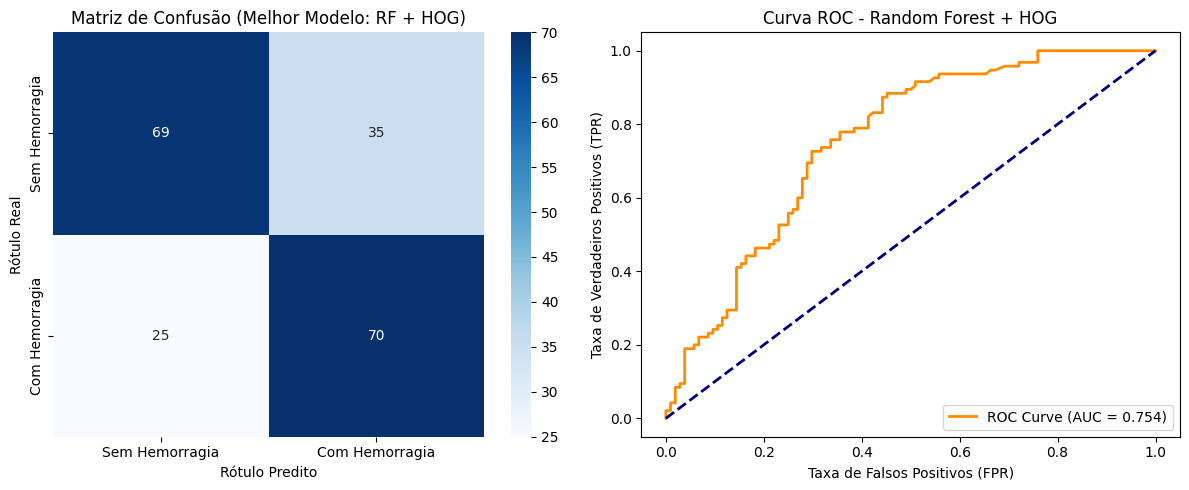

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# LINHA ADICIONADA - corrige o erro (faltava definir os grupos do treino)
groups_train = sample_df.loc[train_mask, 'PatientID']

# 1. Configuração da Validação Cruzada Agrupada por Paciente (5 Folds)
cv_grupo = StratifiedGroupKFold(n_splits=5)

# 2. Grade de Hiperparâmetros para o Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# 3. Busca em Grade com GridSearchCV
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=cv_grupo,
    scoring='roc_auc',
    n_jobs=-1
)

# Assumindo X_hog, y_rotulos e grupos_pacientes do dataset de treino
grid_search.fit(X_train_hog, y_train, groups=groups_train)

best_rf = grid_search.best_estimator_
print("Melhores parâmetros encontrados:", grid_search.best_params_)

# 4. Avaliação Final e Figuras para o Artigo
y_pred_best = best_rf.predict(X_test_hog)
y_prob_best = best_rf.predict_proba(X_test_hog)[:, 1]

# Matrix de Confusão
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Matriz de Confusão
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Sem Hemorragia', 'Com Hemorragia'],
            yticklabels=['Sem Hemorragia', 'Com Hemorragia'])
ax[0].set_title('Matriz de Confusão (Melhor Modelo: RF + HOG)')
ax[0].set_ylabel('Rótulo Real')
ax[0].set_xlabel('Rótulo Predito')

# Gráfico 2: Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
roc_auc_val = auc(fpr, tpr)

ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_val:.3f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlabel('Taxa de Falsos Positivos (FPR)')
ax[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax[1].set_title('Curva ROC - Random Forest + HOG')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('figuras_finais_modelo.png', dpi=300)
plt.show()



In [33]:
from sklearn.metrics import balanced_accuracy_score, f1_score, average_precision_score

resultados.append({
    'descritor': 'HOG',
    'modelo': 'Random_Forest_CV_otimizado',
    'acuracia_balanceada': balanced_accuracy_score(y_test, y_pred_best),
    'f1': f1_score(y_test, y_pred_best, zero_division=0),
    'auc_roc': roc_auc_val,
    'auc_pr': average_precision_score(y_test, y_prob_best)
})

tabela_resultados = pd.DataFrame(resultados).drop_duplicates().reset_index(drop=True)
tabela_resultados.to_csv('tabela_resultados.csv', index=False)
tabela_resultados

,descritor,modelo,acuracia_balanceada,f1,auc_roc,auc_pr
0,baseline_trivial,DummyClassifier,0.500000,0.646300,0.500000,NaN
1,LBP,SVM_RBF,0.660071,0.690583,0.709717,0.639872
2,HOG,SVM_RBF,0.700152,0.700000,0.729858,0.650278
3,Hu_Moments,SVM_RBF,0.581781,0.635193,0.622773,0.572241
4,HOG,Random_Forest_CV_otimizado,0.700152,0.700000,0.753745,0.689507


In [34]:
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score, average_precision_score

# recupera as métricas do Random Forest simples e do kNN (já treinados antes)
pred_rf = rf_model.predict(X_test_hog)
prob_rf = rf_model.predict_proba(X_test_hog)[:, 1]

pred_knn = knn_model.predict(X_test_hog)
prob_knn = knn_model.predict_proba(X_test_hog)[:, 1]

resultados.append({
    'descritor': 'HOG', 'modelo': 'Random_Forest',
    'acuracia_balanceada': balanced_accuracy_score(y_test, pred_rf),
    'f1': f1_score(y_test, pred_rf, zero_division=0),
    'auc_roc': roc_auc_score(y_test, prob_rf),
    'auc_pr': average_precision_score(y_test, prob_rf)
})

resultados.append({
    'descritor': 'HOG', 'modelo': 'kNN',
    'acuracia_balanceada': balanced_accuracy_score(y_test, pred_knn),
    'f1': f1_score(y_test, pred_knn, zero_division=0),
    'auc_roc': roc_auc_score(y_test, prob_knn),
    'auc_pr': average_precision_score(y_test, prob_knn)
})

tabela_resultados = pd.DataFrame(resultados).drop_duplicates().reset_index(drop=True)
tabela_resultados.to_csv('tabela_resultados.csv', index=False)
tabela_resultados

,descritor,modelo,acuracia_balanceada,f1,auc_roc,auc_pr
0,baseline_trivial,DummyClassifier,0.500000,0.646300,0.500000,NaN
1,LBP,SVM_RBF,0.660071,0.690583,0.709717,0.639872
2,HOG,SVM_RBF,0.700152,0.700000,0.729858,0.650278
3,Hu_Moments,SVM_RBF,0.581781,0.635193,0.622773,0.572241
4,HOG,Random_Forest_CV_otimizado,0.700152,0.700000,0.753745,0.689507
5,HOG,Random_Forest,0.720749,0.722772,0.757287,0.694018
6,HOG,kNN,0.659413,0.656566,0.686791,0.603972


In [35]:
import matplotlib.pyplot as plt

# identifica os índices de falso positivo e falso negativo do RF (melhor modelo)
test_ids = sample_df.loc[test_mask, 'image_id'].reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
pred_rf_reset = pd.Series(pred_rf).reset_index(drop=True)

falsos_positivos = test_ids[(y_test_reset == 0) & (pred_rf_reset == 1)].tolist()
falsos_negativos = test_ids[(y_test_reset == 1) & (pred_rf_reset == 0)].tolist()
acertos_positivos = test_ids[(y_test_reset == 1) & (pred_rf_reset == 1)].tolist()

print("Falsos positivos:", len(falsos_positivos))
print("Falsos negativos:", len(falsos_negativos))
print("Acertos (verdadeiro positivo):", len(acertos_positivos))

Falsos positivos: 34
Falsos negativos: 22
Acertos (verdadeiro positivo): 73


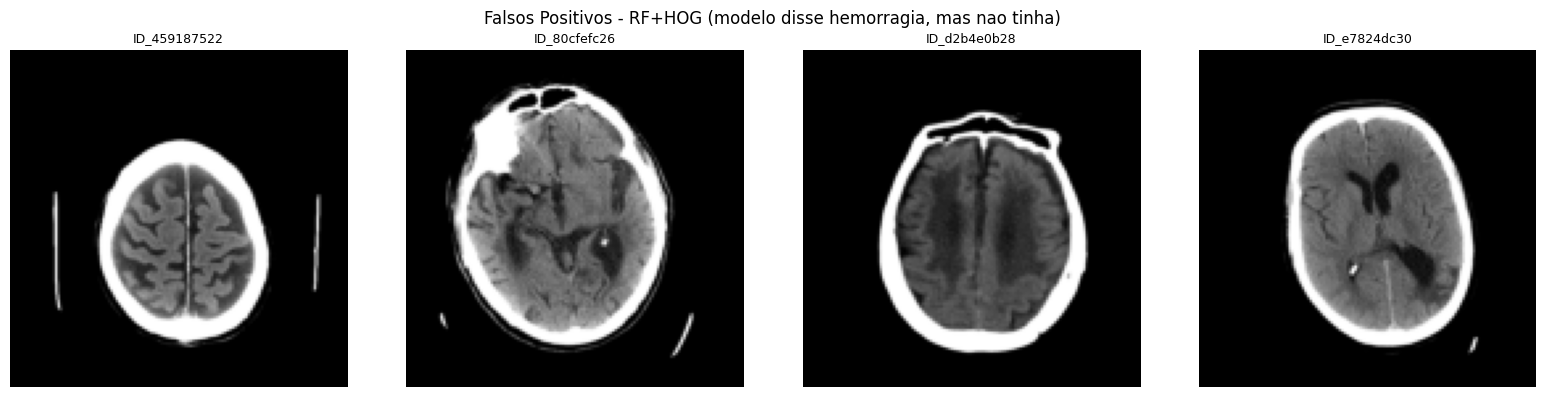

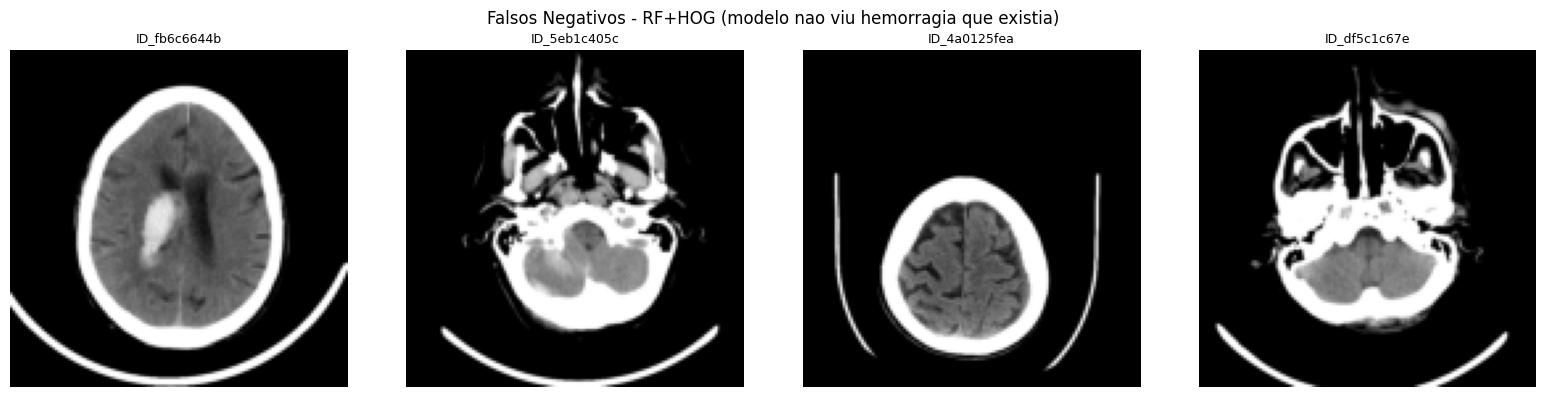

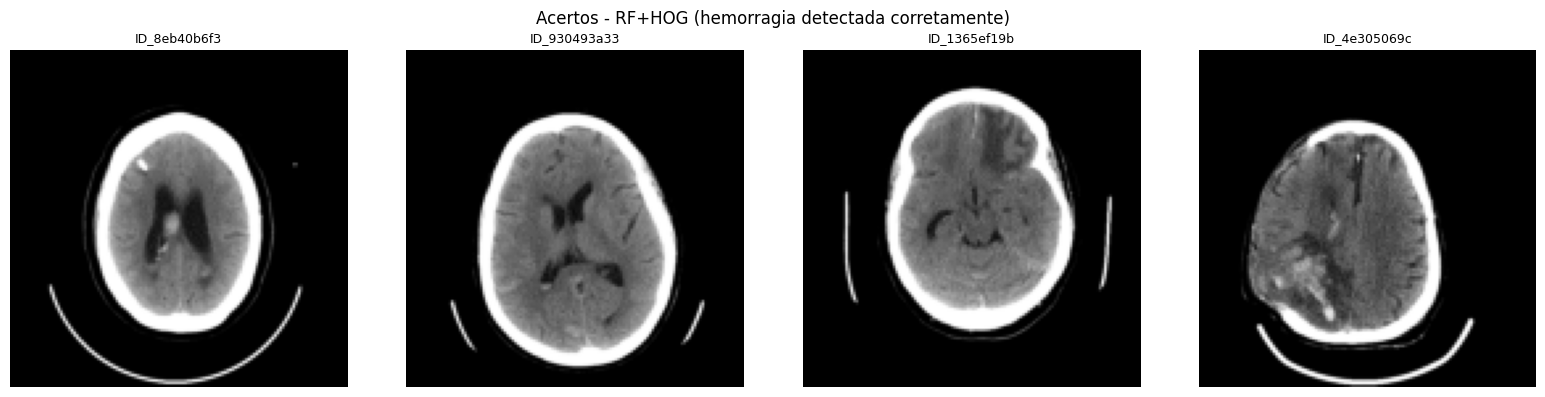

In [36]:
def mostrar_exemplos(lista_ids, titulo, n=4):
    ids_amostra = lista_ids[:n]
    fig, axes = plt.subplots(1, len(ids_amostra), figsize=(4*len(ids_amostra), 4))
    if len(ids_amostra) == 1:
        axes = [axes]
    for ax, img_id in zip(axes, ids_amostra):
        img = carregar_e_janelar(img_id)
        ax.imshow(img, cmap='gray')
        ax.set_title(img_id, fontsize=9)
        ax.axis('off')
    plt.suptitle(titulo)
    plt.tight_layout()
    plt.savefig(f'{titulo.replace(" ", "_")}.png', dpi=150)
    plt.show()

mostrar_exemplos(falsos_positivos, "Falsos Positivos - RF+HOG (modelo disse hemorragia, mas nao tinha)")
mostrar_exemplos(falsos_negativos, "Falsos Negativos - RF+HOG (modelo nao viu hemorragia que existia)")
mostrar_exemplos(acertos_positivos, "Acertos - RF+HOG (hemorragia detectada corretamente)")